In [1]:
import numpy as np
from matplotlib import pyplot as plt
import pandas as pd
from pathlib import Path
import pynapple as nap

from scipy.stats import gaussian_kde

from spatial_manifolds.data.binning import get_bin_config
from spatial_manifolds.data.loading import load_session
from spatial_manifolds.detect_grids import *
import warnings
warnings.filterwarnings('ignore')
%load_ext autoreload
%autoreload 2


In [ ]:
# Load session
gcs_ = pd.DataFrame()
ngs_ = pd.DataFrame()
ns_ = pd.DataFrame()
sc_ = pd.DataFrame()
ngs_ns_ = pd.DataFrame()
all_ = pd.DataFrame()

mouse_days = {20: [14,15,16,17,18,19,20,21,22,23,24,25,26],
              21: [15,16,17,18,19,20,21,22,23,24,25,26],
              25: [16,17,18,19,20,21,22,23,24,25],
              26: [11,12,13,14,15,16,17,18,19],
              27: [16,17,18,19,20,21,22,23,24,26],
              28: [16,17,18,19,20,21,22,23,25],
              29: [16,17,18,19,20,21,22,23,25],
            }

for mouse, days in mouse_days.items():
    for day in days:

        # remove M22 
        if mouse == 22:
            continue

        [gcs, ngs, ns, sc, ngs_ns, all] = cell_classification_of1(mouse, day)
        _,_,_,_,_,clusters_VR = compute_vr_tcs(mouse, day)

        # add columns for all cells whether the use_optimal_travel is True or False
        for cells in [gcs, ngs, ns, sc, ngs_ns, all]:
            cells['use_optimal_travel'] = np.repeat(use_optimal_travel, len(cells))
            
        gcs = load_cluster_locations(clusters_VR, cells=gcs)
        ngs = load_cluster_locations(clusters_VR, cells=ngs)
        ns = load_cluster_locations(clusters_VR, cells=ns)
        sc = load_cluster_locations(clusters_VR, cells=sc)
        ngs_ns = load_cluster_locations(clusters_VR, cells=ngs_ns)
        all = load_cluster_locations(clusters_VR, cells=all)
        
        gcs_ = pd.concat([gcs_, gcs], ignore_index=True)
        ngs_ = pd.concat([ngs_, ngs], ignore_index=True)
        ns_ = pd.concat([ns_, ns], ignore_index=True)
        sc_ = pd.concat([sc_, sc], ignore_index=True)
        ngs_ns_ = pd.concat([ngs_ns_, ngs_ns], ignore_index=True)
        all_ = pd.concat([all_, all], ignore_index=True)

    print(f'there are this many cells at the moment, {len(all_)}')

20 14
optimal travel lag is 0.2502502502502537 cm
there are 169 non_grid and non_spatial_cells
there are 0 grid_cells
there are 93 non grid spatial cells
there are 76 non spatial cells
there are 35 speed cells
there are 204 cells
for the non-grid spatial cells the unique locations are ['ENTm1' 'ENTm2' 'ENTm3' 'ENTm5']
20 15
optimal travel lag is 3.753753753753756 cm
there are 61 non_grid and non_spatial_cells
there are 1 grid_cells
there are 50 non grid spatial cells
there are 11 non spatial cells
there are 11 speed cells
there are 73 cells
for the non-grid spatial cells the unique locations are ['ENTm2' 'ENTm3' 'ENTm5']
for the grid cells the unique locations are ['ENTm3']
20 16
optimal travel lag is 10.860860860860868 cm
there are 178 non_grid and non_spatial_cells
there are 3 grid_cells
there are 156 non grid spatial cells
there are 22 non spatial cells
there are 38 speed cells
there are 219 cells
for the non-grid spatial cells the unique locations are ['ENTm3']
for the grid cells t

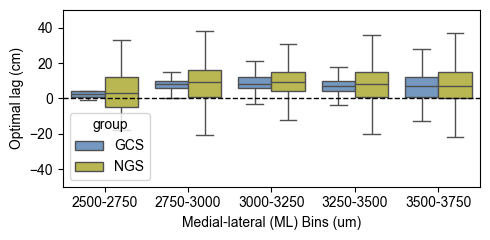

In [45]:
import seaborn as sns
gcs_df = gcs_.copy()
ngs_df = ngs_.copy()    

# Define bins and labels
bins = np.arange(2500, 4000, 250)
bins = np.append(bins, 3750)
bins = np.unique(bins)
labels = [f'{int(b)}-{int(b+250)}' for b in bins[:-1]]

# Bin the data
gcs_df['bin'] = pd.cut(gcs_df['coord_SCs_x']*-1, bins=bins, labels=labels, include_lowest=True)
ngs_df['bin'] = pd.cut(ngs_df['coord_SCs_x']*-1, bins=bins, labels=labels, include_lowest=True)

# Add group labels and reset index to avoid duplicate index issues
gcs_df['group'] = 'GCS'
ngs_df['group'] = 'NGS'
gcs_df.reset_index(drop=True, inplace=True)
ngs_df.reset_index(drop=True, inplace=True)

# Combine data for plotting
combined = pd.concat([gcs_df, ngs_df], ignore_index=True)

# Create a combined boxplot
plt.figure(figsize=(5, 2.5))
bp = sns.boxplot(data=combined, x='bin', y='optimal_travel_lag', 
            hue='group',palette={'GCS': '#6897CD', 'NGS': '#CAC841'}, showfliers=False)

for patch in bp.artists:
    patch.set_alpha(0.5)

plt.axhline(y=0, color='black', linestyle='--', linewidth=1)
plt.xlabel('Medial-lateral (ML) Bins (um)')
plt.ylabel('Optimal lag (cm)')
plt.ylim(-50, 50)
plt.tight_layout()
plt.savefig(f'/Users/harryclark/Desktop/Nature2026 Figs/Figure1_plots/optimal_spatial_information_lag_ML.pdf', bbox_inches='tight')
plt.show()
